In [ ]:
import numpy as np
import pandas as pd



In [ ]:
import pandas as pd
import numpy as np

telemetry = pd.read_csv('PdM_telemetry.csv', parse_dates=['datetime'])
failures  = pd.read_csv('PdM_failures.csv', parse_dates=['datetime'])
maint     = pd.read_csv('PdM_maint.csv', parse_dates=['datetime'])
machines  = pd.read_csv('PdM_machines.csv')
errors    = pd.read_csv('PdM_errors.csv', parse_dates=['datetime'])

print(telemetry.shape, failures.shape, maint.shape, machines.shape, errors.shape)
telemetry.head()

(11579, 6) (761, 3) (3286, 3) (100, 3) (3919, 3)


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [ ]:
# Combine failures and maintenance as "reset events" (component clock resets)
resets = pd.concat([
    failures[['datetime', 'machineID']],
    maint[['datetime', 'machineID']]
]).drop_duplicates().sort_values(['machineID', 'datetime'])

def compute_rul(machine_id, telemetry_df, resets_df):
    tel = telemetry_df[telemetry_df.machineID == machine_id].sort_values('datetime').copy()
    reset_times = resets_df[resets_df.machineID == machine_id]['datetime'].sort_values().values

    if len(reset_times) == 0:
        tel['RUL'] = np.nan
        return tel

    rul_values = []
    for t in tel['datetime'].values:
        future_resets = reset_times[reset_times > t]
        if len(future_resets) == 0:
            rul_values.append(np.nan)  # no future failure known — drop later
        else:
            next_reset = future_resets[0]
            rul_hours = (next_reset - t) / np.timedelta64(1, 'h')
            rul_values.append(rul_hours)

    tel['RUL'] = rul_values
    return tel

all_data = []
for mid in telemetry['machineID'].unique():
    all_data.append(compute_rul(mid, telemetry, resets))

df = pd.concat(all_data, ignore_index=True)
df = df.dropna(subset=['RUL'])  # drop rows with no known future failure
print(df.shape)
df.head()

(11554, 7)


,datetime,machineID,volt,rotate,pressure,vibration,RUL
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,96.0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,95.0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,94.0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,93.0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,92.0


In [ ]:
df = df.sort_values(['machineID', 'datetime'])

window = 24  # 24-hour rolling window
sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']

for col in sensor_cols:
    df[f'{col}_roll_mean'] = df.groupby('machineID')[col].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    df[f'{col}_roll_std'] = df.groupby('machineID')[col].transform(
        lambda x: x.rolling(window, min_periods=1).std())

df[[c for c in df.columns if 'roll' in c]] = df[[c for c in df.columns if 'roll' in c]].fillna(0)

In [ ]:
errors_24h = errors.copy()
errors_24h['datetime'] = errors_24h['datetime'].dt.floor('h')

error_counts = errors_24h.groupby(['machineID', 'datetime']).size().reset_index(name='error_count')

df = df.merge(error_counts, on=['machineID', 'datetime'], how='left')
df['error_count'] = df['error_count'].fillna(0)

In [ ]:
df = df.merge(machines, on='machineID', how='left')
df = pd.get_dummies(df, columns=['model'], drop_first=True)

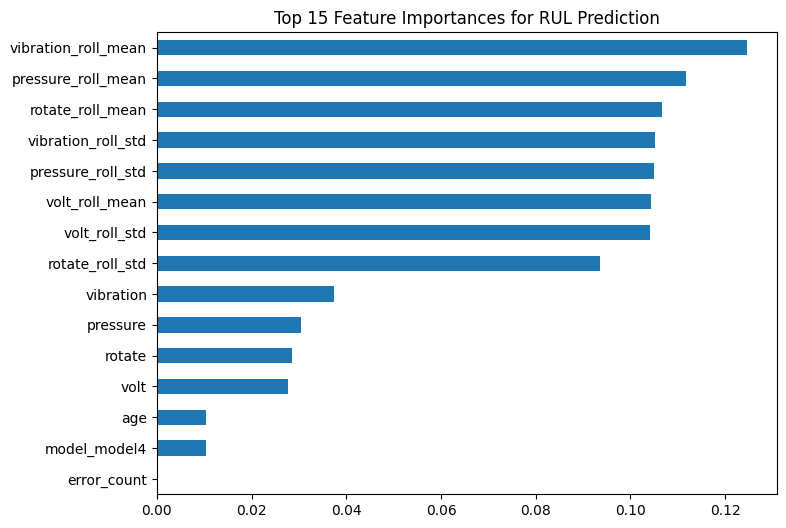

In [ ]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances for RUL Prediction')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_cols = [c for c in df.columns if c not in ['datetime', 'machineID', 'RUL']]
X = df[feature_cols]
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")
print(f"R²: {r2:.3f}")

MAE: 75.50 hours
RMSE: 99.69 hours
R²: 0.364


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preds = model.predict(X_test)

# 1. Standard regression accuracy metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.2f} hours   (on average, predictions are off by this many hours)")
print(f"RMSE: {rmse:.2f} hours  (like MAE, but punishes big mistakes harder)")
print(f"R²:   {r2:.3f}          (0 = useless, 1 = perfect fit)")

# 2. "Accuracy within tolerance" — easier to explain in a report
# e.g. "what % of predictions were within 10 hours of the true RUL?"
tolerance = 10  # hours — pick whatever threshold makes sense for your use case
within_tolerance = np.abs(y_test.values - preds) <= tolerance
accuracy_like_score = within_tolerance.mean()

print(f"Accuracy (within ±{tolerance}h): {accuracy_like_score:.2%}")


MAE:  75.50 hours   (on average, predictions are off by this many hours)
RMSE: 99.69 hours  (like MAE, but punishes big mistakes harder)
R²:   0.364          (0 = useless, 1 = perfect fit)
Accuracy (within ±10h): 8.61%


In [ ]:
from sklearn.metrics import accuracy_score

# y_true = actual/ground truth labels
# y_pred = predicted labels from your model
y_true = [0, 1, 1, 0, 1, 0, 1, 1]
y_pred = [0, 1, 0, 0, 1, 1, 1, 1]

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 75.00%


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming y_test and preds are already defined from your model training
# If not, please run the cells that define X_test, y_test, and model.predict(X_test)

# Calculate regression metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("--- RUL Prediction Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} hours")
print(f"R-squared (R²): {r2:.3f}")

# Calculate 'Accuracy within Tolerance'
tolerance = 10 # hours - adjust this threshold as needed
within_tolerance = np.abs(y_test.values - preds) <= tolerance
accuracy_like_score = within_tolerance.mean()
print(f"Accuracy (predictions within ±{tolerance} hours): {accuracy_like_score:.2%}")

--- RUL Prediction Model Evaluation ---
Mean Absolute Error (MAE): 75.50 hours
Root Mean Squared Error (RMSE): 99.69 hours
R-squared (R²): 0.364
Accuracy (predictions within ±10 hours): 8.61%


In [ ]:
import joblib
joblib.dump(model, 'filename.joblib')

['filename.joblib']